In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from collections import Counter
from tensorflow.keras.datasets import cifar10, cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

import random

In [4]:
np.random.seed(42)
random.seed(42)

In [5]:
print ("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# Load CIFAR -10

In [6]:
(x10_train, y10_train), (x10_test, y10_test) = cifar10.load_data()

print("CIFAR-10")
print(f"Training Images: {x10_train.shape[0]}")
print(f"Training Labels: {y10_train.shape[0]}")
print(f"Test Images: {x10_test.shape[0]}")
print(f"Test Labels: {y10_test.shape[0]}")

CIFAR-10
Training Images: 50000
Training Labels: 50000
Test Images: 10000
Test Labels: 10000


# Load CIFAR - 100

In [7]:
(x100_train, y100_train), (x100_test, y100_test) = cifar100.load_data()

print("\nCIFAR-100")
print(f"Training Images: {x100_train.shape[0]}")
print(f"Training Labels: {y100_train.shape[0]}")
print(f"Test Images: {x100_test.shape[0]}")
print(f"Test Labels: {y100_test.shape[0]}")


CIFAR-100
Training Images: 50000
Training Labels: 50000
Test Images: 10000
Test Labels: 10000


# CIFAR - 10 Classes

In [8]:
cifar10_classes = ['airplane', 
                   'automobile', 
                    'bird', 
                    'cat', 
                    'deer', 
                    'dog', 
                    'frog', 
                    'horse', 
                    'ship', 
                    'truck']

required_classes = ['automobile', 'bird', 'cat', 'deer', 'dog', 'horse','truck']

# CIFAR - 100 Classes

In [9]:
cifar100_classes = [
    "apple","aquarium_fish","baby","bear","beaver","bed","bee","beetle",
    "bicycle","bottle","bowl","boy","bridge","bus","butterfly","camel",
    "can","castle","caterpillar","cattle","chair","chimpanzee","clock",
    "cloud","cockroach","couch","crab","crocodile","cup","dinosaur",
    "dolphin","elephant","flatfish","forest","fox","girl","hamster",
    "house","kangaroo","keyboard","lamp","lawn_mower","leopard","lion",
    "lizard","lobster","man","maple_tree","motorcycle","mountain","mouse",
    "mushroom","oak_tree","orange","orchid","otter","palm_tree","pear",
    "pickup_truck","pine_tree","plain","plate","poppy","porcupine",
    "possum","rabbit","raccoon","ray","road","rocket","rose","sea",
    "seal","shark","shrew","skunk","skyscraper","snail","snake",
    "spider","squirrel","streetcar","sunflower","sweet_pepper","table",
    "tank","telephone","television","tiger","tractor","train","trout",
    "tulip","turtle","wardrobe","whale","willow_tree","wolf","woman",
    "worm"
]

# Final Classes

In [10]:
final_classes = ["automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "horse",
    "truck",
    "cattle",
    "fox",
    "baby",
    "boy",
    "girl",
    "man",
    "woman",
    "rabbit",
    "squirrel",
    "trees",
    "bicycle",
    "bus",
    "motorcycle",
    "pickup_truck",
    "train",
    "lawn_mower",
    "tractor"]

In [11]:
final_class_to_label = {class_name: label for label, class_name in enumerate(final_classes)}

print("Number of final classes:", len(final_classes))
print("\nFinal label mapping:")
for class_name, label in final_class_to_label.items():
    print(f"  {label:2d}: {class_name}")

Number of final classes: 24

Final label mapping:
   0: automobile
   1: bird
   2: cat
   3: deer
   4: dog
   5: horse
   6: truck
   7: cattle
   8: fox
   9: baby
  10: boy
  11: girl
  12: man
  13: woman
  14: rabbit
  15: squirrel
  16: trees
  17: bicycle
  18: bus
  19: motorcycle
  20: pickup_truck
  21: train
  22: lawn_mower
  23: tractor


In [12]:
y10_train = y10_train.flatten() 
y10_test = y10_test.flatten()

y100_train = y100_train.flatten()
y100_test = y100_test.flatten()

print("CIFAR-10 training labels shape:", y10_train.shape)

print("CIFAR-100 training labels shape:", y100_train.shape)


CIFAR-10 training labels shape: (50000,)
CIFAR-100 training labels shape: (50000,)


In [13]:
def extract_cifaar10_classes(images,labels):
    selected_images = []
    selected_labels = []

    for class_name in required_classes:
        original_label = cifar10_classes.index(class_name)

        class_mask = labels == original_label
        class_images = images[class_mask]

        new_label = final_class_to_label[class_name]
        class_labels = np.full(len(class_images), fill_value=new_label, dtype=np.int32)

        selected_images.append(class_images)
        selected_labels.append(class_labels)

    selected_images = np.concatenate(selected_images, axis=0)
    selected_labels = np.concatenate(selected_labels, axis=0)

    return selected_images, selected_labels

In [14]:
x10_train_selected, y10_train_selected = extract_cifaar10_classes(x10_train, y10_train)
x10_test_selected, y10_test_selected = extract_cifaar10_classes(x10_test, y10_test)

print("CIFAR-10 selected training images shape:", x10_train_selected.shape)
print("CIFAR-10 selected training labels shape:", y10_train_selected.shape)

print("CIFAR-10 selected test images shape:", x10_test_selected.shape)
print("CIFAR-10 selected test labels shape:", y10_test_selected.shape)

CIFAR-10 selected training images shape: (35000, 32, 32, 3)
CIFAR-10 selected training labels shape: (35000,)
CIFAR-10 selected test images shape: (7000, 32, 32, 3)
CIFAR-10 selected test labels shape: (7000,)


# Merge the selected datasets

In [15]:
x_train_combined = np.concatenate((x10_train_selected, x100_train), axis=0)
y_train_combined = np.concatenate((y10_train_selected, y100_train), axis=0)

x_test_combined = np.concatenate((x10_test_selected, x100_test), axis=0)
y_test_combined = np.concatenate((y10_test_selected, y100_test), axis=0)

print("Combined training images shape:", x_train_combined.shape)
print("Combined training labels shape:", y_train_combined.shape)

print("Combined test images shape:", x_test_combined.shape)
print("Combined test labels shape:", y_test_combined.shape)

Combined training images shape: (85000, 32, 32, 3)
Combined training labels shape: (85000,)
Combined test images shape: (17000, 32, 32, 3)
Combined test labels shape: (17000,)


In [16]:
print("Training images shape:", x_train_combined.shape)
print("Training labels shape:", y_train_combined.shape)

print("\nTest images shape:", x_test_combined.shape)
print("Test labels shape:", y_test_combined.shape)

print("\nNumber of unique classes in training labels:")
print(len(np.unique(y_train_combined)))

print("\nUnique labels:")
print(np.unique(y_train_combined))


Training images shape: (85000, 32, 32, 3)
Training labels shape: (85000,)

Test images shape: (17000, 32, 32, 3)
Test labels shape: (17000,)

Number of unique classes in training labels:
100

Unique labels:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


# Exploring the Combined Dataset

In [17]:
print("Training images shape:", x_train_combined.shape)
print("Training labels shape:", y_train_combined.shape)

print("Test images shape:", x_test_combined.shape)
print("Test labels shape:", y_test_combined.shape)

print("Number of classes:", len(final_classes))

Training images shape: (85000, 32, 32, 3)
Training labels shape: (85000,)
Test images shape: (17000, 32, 32, 3)
Test labels shape: (17000,)
Number of classes: 24


In [18]:
train_class_counts = Counter(y_train_combined)
test_class_counts = Counter(y_test_combined)

print("Training set class distribution:\n")

for label, class_name in enumerate(final_classes):
    print(
        f"{label:2d} - {class_name:15s}: "
        f"{train_class_counts[label]} training images"
        f"{test_class_counts[label]} test images"
    )

Training set class distribution:

 0 - automobile     : 5500 training images1100 test images
 1 - bird           : 5500 training images1100 test images
 2 - cat            : 5500 training images1100 test images
 3 - deer           : 5500 training images1100 test images
 4 - dog            : 5500 training images1100 test images
 5 - horse          : 5500 training images1100 test images
 6 - truck          : 5500 training images1100 test images
 7 - cattle         : 500 training images100 test images
 8 - fox            : 500 training images100 test images
 9 - baby           : 500 training images100 test images
10 - boy            : 500 training images100 test images
11 - girl           : 500 training images100 test images
12 - man            : 500 training images100 test images
13 - woman          : 500 training images100 test images
14 - rabbit         : 500 training images100 test images
15 - squirrel       : 500 training images100 test images
16 - trees          : 500 training image

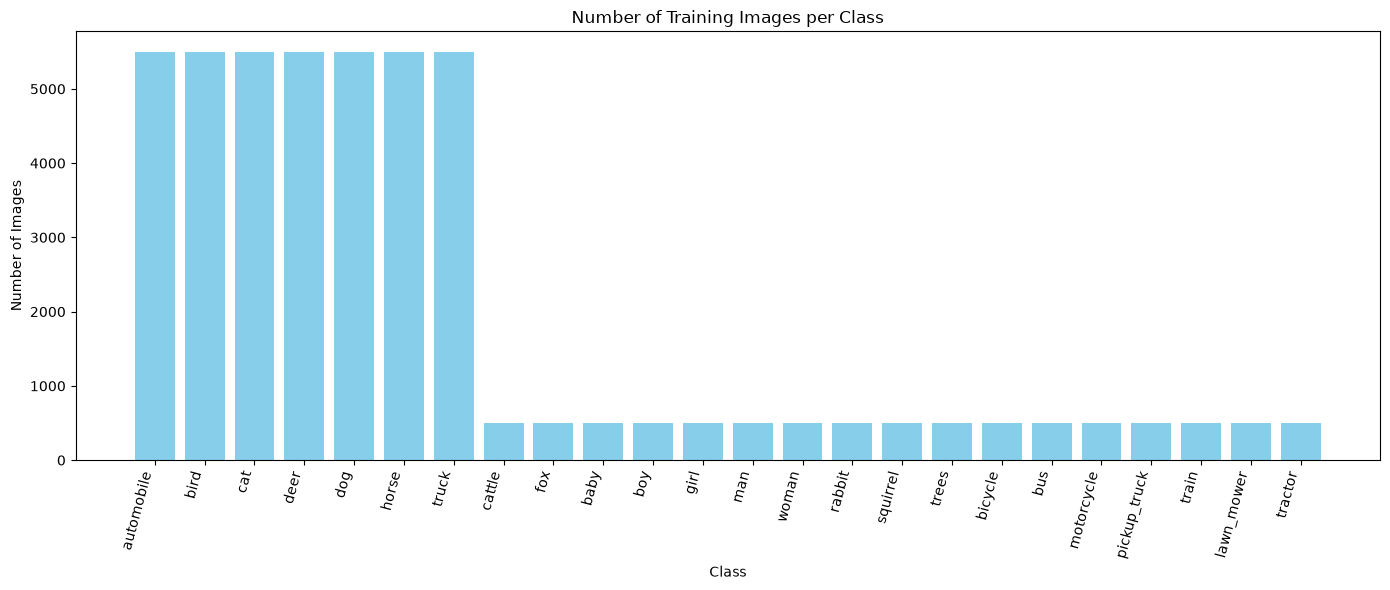

In [19]:
class_labels = np.arange(len(final_classes))

training_counts = [
    train_class_counts[label] for label in class_labels
]

plt.figure(figsize=(14, 6))

plt.bar(class_labels, training_counts, color='skyblue')

plt.xticks(class_labels, final_classes, rotation=75, ha='right')

plt.title("Number of Training Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()